# Recommendation System - Movie Recommendation
## This notebook outlines the concepts involved in building a Complete Recommendation System for recommending Movies to users
## Movie Recommender System - A very very very simple Clone of Netflix

**MovieLens dataset** and build a model to **recommend movies** to the end users. This data has been collected by the GroupLens Research Project at the University of Minnesota. 

This dataset consists of:
- **100,000 ratings** (1-5) from **943 users** on **1682 movies**
- Demographic information of the users (age, gender, occupation, etc.)

Dataset: 

### Import the libraries

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

### Download the dataset

In [3]:
#! wget https://raw.githubusercontent.com/subashgandyer/datasets/main/ml-100k/ml-100k.zip

In [4]:
#! unzip ml-100k.zip

In [5]:
import zipfile

# 指定 ZIP 檔案名稱
zip_file = "ml-100k.zip"

# 解壓縮
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("ml-100k")  # 這裡是解壓縮的目標資料夾


### Load the dataset
### Reading users file
- u.user

- Please check the column names from the readme file
- Pass in column names for each CSV as the column name is not given in the file and read them using pandas
- Use these following columns
    - 'user_id', 'age', 'sex', 'occupation', 'zip_code'

In [16]:
u_cols = ['user_id', 'age', 'sex', 'occupation', 'zip_code']
users = pd.read_csv('ml-100k/u.data', sep='|', names=u_cols,encoding='latin-1')

In [18]:
print("\nUser Data :")
print("shape : ", users.shape)
print(users.head())


User Data :
shape :  (100000, 5)
                  user_id  age  sex  occupation  zip_code
0  196\t242\t3\t881250949  NaN  NaN         NaN       NaN
1  186\t302\t3\t891717742  NaN  NaN         NaN       NaN
2   22\t377\t1\t878887116  NaN  NaN         NaN       NaN
3   244\t51\t2\t880606923  NaN  NaN         NaN       NaN
4  166\t346\t1\t886397596  NaN  NaN         NaN       NaN


In [11]:
u_cols = ['user_id', 'age', 'sex', 'occupation', 'zip_code']
users = pd.read_csv('ml-100k/u.user', sep='|', names=u_cols,encoding='latin-1')

### Display the user data

In [14]:
print("\nUser Data :")
print("shape : ", users.shape)
print(users.head())


User Data :
shape :  (943, 5)
   user_id  age sex  occupation zip_code
0        1   24   M  technician    85711
1        2   53   F       other    94043
2        3   23   M      writer    32067
3        4   24   M  technician    43537
4        5   33   F       other    15213


In [13]:
users

,user_id,age,sex,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213
...,...,...,...,...,...
938,939,26,F,student,33319
939,940,32,M,administrator,02215
940,941,20,M,student,97229
941,942,48,F,librarian,78209


### Reading ratings file
- u.data
- Use the following columns
    - 'user_id', 'movie_id', 'rating', 'unix_timestamp'

In [15]:
r_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']
ratings = pd.read_csv('ml-100k/u.data', sep='\t', names=r_cols,encoding='latin-1')

### Display the Ratings data

In [18]:
print("\nRatings Data :")
print("shape : ", ratings.shape)
print(ratings.head())


Ratings Data :
shape :  (100000, 4)
   user_id  movie_id  rating  unix_timestamp
0      196       242       3       881250949
1      186       302       3       891717742
2       22       377       1       878887116
3      244        51       2       880606923
4      166       346       1       886397596


### Reading items file
- u.item
- Use the following columns
    - 'movie id', 'movie title' ,'release date','video release date', 'IMDb URL', 'unknown', 'Action', 'Adventure',
    - 'Animation', 'Children\'s', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
    - 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'

In [20]:
i_cols = ['movie_id', 'movie_title' ,'release date','video release date', 'IMDb URL', 'unknown', 'Action', 'Adventure',
'Animation', 'Children\'s', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
items = pd.read_csv('ml-100k/u.item', sep='|', names=i_cols,encoding='latin-1')

### Display the Items data

In [23]:
print("\nItem Data :")
print("shape : ", items.shape)
print(items.head())


Item Data :
shape :  (1682, 24)
   movie_id        movie_title release date  video release date  \
0         1   Toy Story (1995)  01-Jan-1995                 NaN   
1         2   GoldenEye (1995)  01-Jan-1995                 NaN   
2         3  Four Rooms (1995)  01-Jan-1995                 NaN   
3         4  Get Shorty (1995)  01-Jan-1995                 NaN   
4         5     Copycat (1995)  01-Jan-1995                 NaN   

                                            IMDb URL  unknown  Action  \
0  http://us.imdb.com/M/title-exact?Toy%20Story%2...        0       0   
1  http://us.imdb.com/M/title-exact?GoldenEye%20(...        0       1   
2  http://us.imdb.com/M/title-exact?Four%20Rooms%...        0       0   
3  http://us.imdb.com/M/title-exact?Get%20Shorty%...        0       1   
4  http://us.imdb.com/M/title-exact?Copycat%20(1995)        0       0   

   Adventure  Animation  Children's  ...  Fantasy  Film-Noir  Horror  Musical  \
0          0          1           1  ...    

### Reading Training and Testing Ratings data
- Training
    - ua.base
- Testing
    - ua.test
- Use the following columns
    - 'user_id', 'movie_id', 'rating', 'unix_timestamp'

In [25]:
r_cols = ['user_id', 'movie_id', 'rating', 'unix_timestamp']
ratings_train = pd.read_csv('ml-100k/ua.base', sep='\t', names=r_cols, encoding='latin-1')
ratings_test = pd.read_csv('ml-100k/ua.test', sep='\t', names=r_cols, encoding='latin-1')

### Display the Training and Testing Ratings data

In [27]:
ratings_train.shape, ratings_test.shape

((90570, 4), (9430, 4))

### How many unique users?

In [29]:
n_users = ratings.user_id.unique().shape[0]
n_users

943

### How many unique items / movies?

In [31]:
n_items = ratings.movie_id.unique().shape[0]
n_items

1682

### Create a User-Item Matrix

In [33]:
from scipy.sparse import csr_matrix

In [35]:
user_movies_data = ratings.pivot(index = 'movie_id', columns = 'user_id', values = 'rating').fillna(0)

In [37]:
user_movies_data

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
movie_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,4.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,4.0,...,2.0,3.0,4.0,0.0,4.0,0.0,0.0,5.0,0.0,0.0
2,3.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
3,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,4.0,...,5.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
5,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1678,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


這個矩陣的用途
這個 user_movies_data 矩陣可以作為推薦系統的基礎：

1. 計算相似度
cosine similarity（餘弦相似度）
pearson correlation（皮爾遜相關係數）
2. 基於內容的推薦
分析電影的相似性，根據使用者喜好推薦相似電影。
3. 基於協同過濾的推薦
使用者-使用者協同過濾 (User-User CF)：根據相似使用者的喜好推薦電影。
物品-物品協同過濾 (Item-Item CF)：根據相似電影的評分關係推薦電影。


# 1. Content Filtering

### Data Preparation
Prepare data for Metadata to have a TF-IDF Vectorizer for Content Filtering

In [41]:
items

,movie_id,movie_title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1678,1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
1679,1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1680,1681,You So Crazy (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
items['metadata'] = ""

In [45]:
items

,movie_id,movie_title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,metadata
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,
1678,1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,
1679,1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,
1680,1681,You So Crazy (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,


In [47]:
items.Action, type(items.Action)

(0       0
 1       1
 2       0
 3       1
 4       0
        ..
 1677    0
 1678    0
 1679    0
 1680    0
 1681    0
 Name: Action, Length: 1682, dtype: int64,
 pandas.core.series.Series)

In [49]:
def metadata_Action(x):
    if x == 1:
        return "Action"
    else:
        return " "

In [51]:
items['metadata_Action'] = items.Action.apply(metadata_Action)

In [53]:
items

,movie_id,movie_title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,metadata,metadata_Action
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,,
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,1,0,0,,Action
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,1,0,0,,
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,,Action
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,1,0,0,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,,
1678,1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,...,0,0,0,1,0,1,0,0,,
1679,1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,...,0,0,0,1,0,0,0,0,,
1680,1681,You So Crazy (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,...,0,0,0,0,0,0,0,0,,


In [55]:
def metadata_Adventure(x):
    if x == 1:
        return " Adventure "
    else:
        return " "
    
items['metadata_Adventure'] = items.Adventure.apply(metadata_Adventure)

In [59]:
items

,movie_id,movie_title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,metadata,metadata_Action,metadata_Adventure
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,,,
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,1,0,0,,Action,Adventure
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,1,0,0,,,
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,,Action,
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,1,0,0,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,...,0,0,0,0,0,0,0,,,
1678,1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,...,0,0,1,0,1,0,0,,,
1679,1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,...,0,0,1,0,0,0,0,,,
1680,1681,You So Crazy (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,...,0,0,0,0,0,0,0,,,


In [61]:
genres = ['Action', 'Adventure',
'Animation', 'Children\'s', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

In [63]:
def metadata_Animation(x):
    if x == 1:
        return " Animation "
    else:
        return " "
items['metadata_Animation'] = items.Animation.apply(metadata_Animation)

In [65]:
def metadata_Childrens(x):
    if x == 1:
        return " Children's "
    else:
        return " "
    
items["metadata_Children's"] = items["Children's"].apply(metadata_Childrens)

In [67]:
def metadata_Comedy(x):
    if x == 1:
        return " Comedy "
    else:
        return " "

items['metadata_Comedy'] = items.Comedy.apply(metadata_Comedy)

In [69]:
def metadata_Crime(x):
    if x == 1:
        return " Crime "
    else:
        return " "
    
items['metadata_Crime'] = items.Crime.apply(metadata_Crime)

In [71]:
def metadata_Documentary(x):
    if x == 1:
        return " Documentary "
    else:
        return " "
    
items['metadata_Documentary'] = items.Documentary.apply(metadata_Documentary)

In [73]:
def metadata_Drama(x):
    if x == 1:
        return " Drama "
    else:
        return " "
    
items['metadata_Drama'] = items.Drama.apply(metadata_Drama)

In [75]:
def metadata_Fantasy(x):
    if x == 1:
        return " Fantasy "
    else:
        return " "
    
items['metadata_Fantasy'] = items.Fantasy.apply(metadata_Fantasy)

In [77]:
def metadata_FilmNoir(x):
    if x == 1:
        return " Film-Noir "
    else:
        return " "
    
items['metadata_Film-Noir'] = items["Film-Noir"].apply(metadata_FilmNoir)

In [79]:
def metadata_Horror(x):
    if x == 1:
        return "Horror "
    else:
        return " "

items['metadata_Horror'] = items.Horror.apply(metadata_Horror)

In [81]:
def metadata_Musical(x):
    if x == 1:
        return " Musical "
    else:
        return " "
    
items['metadata_Musical'] = items.Musical.apply(metadata_Musical)

In [83]:
def metadata_Mystery(x):
    if x == 1:
        return " Mystery "
    else:
        return " "
    
items['metadata_Mystery'] = items.Mystery.apply(metadata_Mystery)

In [85]:
def metadata_Romance(x):
    if x == 1:
        return " Romance "
    else:
        return " "
    
items['metadata_Romance'] = items.Romance.apply(metadata_Romance)

In [87]:
def metadata_SciFi(x):
    if x == 1:
        return " Sci-Fi "
    else:
        return " "
    
items['metadata_Sci-Fi'] = items["Sci-Fi"].apply(metadata_SciFi)

In [89]:
def metadata_Thriller(x):
    if x == 1:
        return " Thriller "
    else:
        return " "
    
items['metadata_Thriller'] = items.Thriller.apply(metadata_Thriller)

In [91]:
def metadata_War(x):
    if x == 1:
        return " War "
    else:
        return " "
    
items['metadata_War'] = items.War.apply(metadata_War)

In [93]:
def metadata_Western(x):
    if x == 1:
        return " Western "
    else:
        return " "
    
items['metadata_Western'] = items.Western.apply(metadata_Western)

In [95]:
items

,movie_id,movie_title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,metadata_Fantasy,metadata_Film-Noir,metadata_Horror,metadata_Musical,metadata_Mystery,metadata_Romance,metadata_Sci-Fi,metadata_Thriller,metadata_War,metadata_Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,,,,,,,,,,
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,,,,,,,,Thriller,,
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,,,,,,,,Thriller,,
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,,,,,,,,,,
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,,,,,,,,Thriller,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,...,,,,,,,,,,
1678,1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,...,,,,,,Romance,,Thriller,,
1679,1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,...,,,,,,Romance,,,,
1680,1681,You So Crazy (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,...,,,,,,,,,,


In [97]:
items['full_metadata'] = items[['metadata_Action', 'metadata_Adventure',
'metadata_Animation', 'metadata_Children\'s', 'metadata_Comedy', 'metadata_Crime', 'metadata_Documentary', 'metadata_Drama', 'metadata_Fantasy',
'metadata_Film-Noir', 'metadata_Horror', 'metadata_Musical', 'metadata_Mystery', 'metadata_Romance', 'metadata_Sci-Fi', 'metadata_Thriller', 'metadata_War', 'metadata_Western']].apply(
                                          lambda x: ' '.join(x), axis = 1)
                                
                                

In [99]:
items

,movie_id,movie_title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,metadata_Film-Noir,metadata_Horror,metadata_Musical,metadata_Mystery,metadata_Romance,metadata_Sci-Fi,metadata_Thriller,metadata_War,metadata_Western,full_metadata
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,,,,,,,,,,Animation Children's Comedy ...
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,,,,,,,Thriller,,,Action Adventure ...
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,,,,,,,Thriller,,,Thriller
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,,,,,,,,,,Action Comedy Drama ...
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,,,,,,,Thriller,,,Crime Drama Thr...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,...,,,,,,,,,,Drama
1678,1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,...,,,,,Romance,,Thriller,,,Romance Thrille...
1679,1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,...,,,,,Romance,,,,,Drama Romance
1680,1681,You So Crazy (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,...,,,,,,,,,,Comedy


## TF-IDF Vectorizer on Metadata

In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(items['full_metadata'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=items.index.tolist())
print(tfidf_df.shape)

(1682, 20)


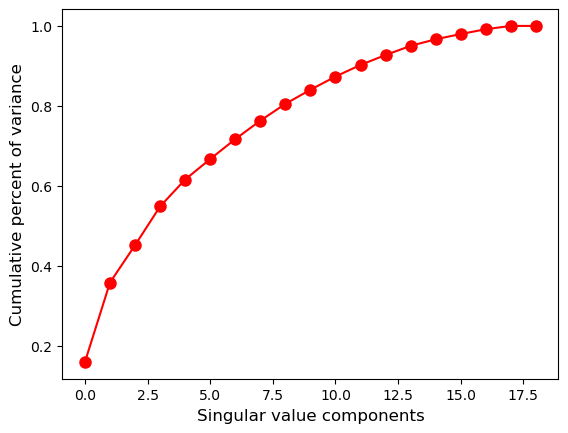

In [107]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=19)
latent_matrix = svd.fit_transform(tfidf_df)
# plot var expalined to see what latent dimensions to use
explained = svd.explained_variance_ratio_.cumsum()
plt.plot(explained, '.-', ms = 16, color='red')
plt.xlabel('Singular value components', fontsize= 12)
plt.ylabel('Cumulative percent of variance', fontsize=12)        
plt.show()

In [109]:
n = 20
latent_matrix_1_df = pd.DataFrame(latent_matrix[:,0:n], index=items.movie_title.tolist())

In [111]:
latent_matrix_1_df.shape

(1682, 19)

## 2. Collaborative Filtering
- Use user_movies_data

In [113]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=200)
latent_matrix_2 = svd.fit_transform(user_movies_data)
latent_matrix_2_df = pd.DataFrame(
                             latent_matrix_2, index=items.movie_title.tolist())

In [115]:
latent_matrix_2_df

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
Toy Story (1995),61.469396,-21.359470,-3.697670,-2.579255,-22.229734,-15.965819,12.771047,2.750648,-6.317180,0.425653,...,-1.785295,-3.128315,1.020354,-0.818081,2.551824,-0.044760,-0.526405,-1.374448,0.753677,0.981789
GoldenEye (1995),22.537180,-1.719990,-13.616243,-0.514689,6.448353,2.408713,0.014408,1.979777,8.063038,-4.683454,...,1.082512,0.319433,1.007735,-0.703575,0.116715,0.383509,1.329384,-0.231898,0.458297,-0.800092
Four Rooms (1995),12.767067,-7.006769,-2.535840,-7.766790,0.696417,4.604113,-0.299383,2.450658,-2.594064,-3.198474,...,0.104862,-1.328707,0.657787,-1.115758,0.075780,0.126775,-2.447252,-1.759979,1.025372,2.428366
Get Shorty (1995),38.407419,3.195162,-5.761061,-6.843529,6.046999,6.969560,-0.931458,-3.538109,5.464866,-6.086682,...,-0.328339,-2.861594,-0.153836,1.345566,0.073869,-0.169262,-2.212414,-0.463922,0.497287,1.069041
Copycat (1995),13.842238,-3.748584,-5.764236,-2.849087,2.476795,4.737294,-6.224758,-0.061704,-2.037485,5.640040,...,1.318018,2.166202,0.643659,-0.836757,2.750455,0.803773,1.253068,0.153323,0.320520,-1.136082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mat' i syn (1997),0.009730,-0.054860,0.058059,0.075857,0.094315,0.020940,0.021501,-0.003021,-0.021639,-0.005758,...,-0.048695,-0.042503,-0.022859,-0.044619,0.000868,-0.059194,0.036586,-0.028864,0.034611,-0.010999
B. Monkey (1998),0.029189,-0.164580,0.174176,0.227572,0.282945,0.062819,0.064502,-0.009064,-0.064918,-0.017274,...,-0.146084,-0.127508,-0.068578,-0.133857,0.002603,-0.177582,0.109759,-0.086592,0.103832,-0.032996
Sliding Doors (1998),0.019459,-0.109720,0.116117,0.151715,0.188630,0.041879,0.043001,-0.006043,-0.043279,-0.011516,...,-0.097390,-0.085005,-0.045718,-0.089238,0.001735,-0.118388,0.073172,-0.057728,0.069221,-0.021997
You So Crazy (1994),0.212086,0.025764,-0.098975,-0.012308,0.071658,-0.018906,-0.086135,-0.047576,0.173650,-0.001902,...,-0.070199,0.219411,0.014363,-0.056587,-0.282914,-0.007526,-0.212552,-0.076394,0.143656,0.042710


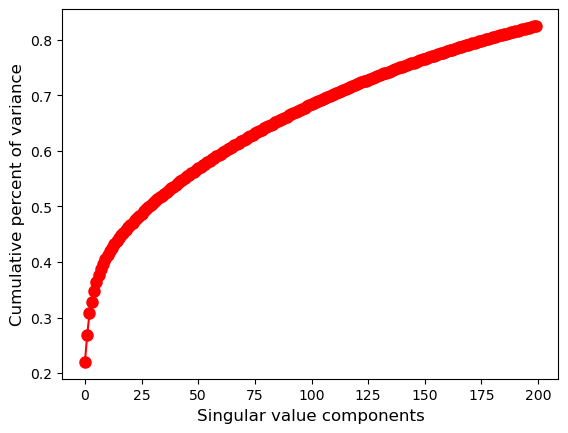

In [117]:
# plot variance expalined to see what latent dimensions to use
explained = svd.explained_variance_ratio_.cumsum()
plt.plot(explained, '.-', ms = 16, color='red')
plt.xlabel('Singular value components', fontsize= 12)
plt.ylabel('Cumulative percent of variance', fontsize=12)        
plt.show()


In [119]:
from sklearn.metrics.pairwise import cosine_similarity
# take the latent vectors for a selected movie from both content 
# and collaborative matrixes
a_1 = np.array(latent_matrix_1_df.loc['Toy Story (1995)']).reshape(1, -1)
a_2 = np.array(latent_matrix_2_df.loc["Toy Story (1995)"]).reshape(1, -1)

# calculate the similartity of this movie with the others in the list
score_1 = cosine_similarity(latent_matrix_1_df, a_1).reshape(-1)
score_2 = cosine_similarity(latent_matrix_2_df, a_2).reshape(-1)

# an average measure of both content and collaborative 
hybrid = ((score_1 + score_2)/2.0)

# form a data frame of similar movies 
dictDf = {'content': score_1 , 'collaborative': score_2, 'hybrid': hybrid} 
# dictDf = {'collaborative': score_2} 
similar = pd.DataFrame(dictDf, index = latent_matrix_2_df.index )

#sort it on the basis of either: content, collaborative or hybrid, 
# here : content
similar.sort_values('content', ascending=False, inplace=True)

similar[1:].head(11)

,content,collaborative,hybrid
Aladdin and the King of Thieves (1996),1.000000,0.335740,0.667870
"Fox and the Hound, The (1981)",0.936967,0.402432,0.669699
Gumby: The Movie (1995),0.936967,0.123260,0.530113
Land Before Time III: The Time of the Great Giving (1995) (V),0.936967,0.173761,0.555364
"Swan Princess, The (1994)",0.936967,0.135277,0.536122
"Sword in the Stone, The (1963)",0.936967,0.419333,0.678150
Oliver & Company (1988),0.936967,0.234544,0.585755
Balto (1995),0.936967,0.192701,0.564834
"Aristocats, The (1970)",0.936967,0.329420,0.633194
Pinocchio (1940),0.936967,0.444121,0.690544


In [121]:
similar.sort_values('collaborative', ascending=False, inplace=True)

similar[1:].head(11)

,content,collaborative,hybrid
Star Wars (1977),-1.040834e-17,0.760043,0.380021
Independence Day (ID4) (1996),5.551115e-17,0.722489,0.361245
Return of the Jedi (1983),-1.040834e-17,0.718676,0.359338
"Rock, The (1996)",-1.387779e-16,0.695955,0.347977
Mission: Impossible (1996),-1.665335e-16,0.680880,0.340440
Willy Wonka and the Chocolate Factory (1971),5.168978e-01,0.665360,0.591129
Star Trek: First Contact (1996),1.387779e-17,0.655977,0.327988
Twister (1996),-1.387779e-16,0.652748,0.326374
Fargo (1996),-2.567391e-16,0.648800,0.324400
Jerry Maguire (1996),7.600257e-17,0.648683,0.324342


In [123]:
similar.sort_values('hybrid', ascending=False, inplace=True)

similar[1:].head(11)

,content,collaborative,hybrid
Aladdin (1992),0.820798,0.612080,0.716439
Pinocchio (1940),0.936967,0.444121,0.690544
"Sword in the Stone, The (1963)",0.936967,0.419333,0.678150
Beauty and the Beast (1991),0.752183,0.591094,0.671639
"Fox and the Hound, The (1981)",0.936967,0.402432,0.669699
"Lion King, The (1994)",0.752183,0.585943,0.669063
Aladdin and the King of Thieves (1996),1.000000,0.335740,0.667870
Winnie the Pooh and the Blustery Day (1968),0.936967,0.384176,0.660571
Beavis and Butt-head Do America (1996),0.818945,0.498427,0.658686
"Aristocats, The (1970)",0.936967,0.329420,0.633194


## 3. Hybrid Recommendation System

In [125]:
def recommend_similar_movies(title):
    # take the latent vectors for a selected movie from both content 
    # and collaborative matrixes
    a_1 = np.array(latent_matrix_1_df.loc[title]).reshape(1, -1)
    a_2 = np.array(latent_matrix_2_df.loc[title]).reshape(1, -1)

    # calculate the similartity of this movie with the others in the list
    score_1 = cosine_similarity(latent_matrix_1_df, a_1).reshape(-1)
    score_2 = cosine_similarity(latent_matrix_2_df, a_2).reshape(-1)

    # an average measure of both content and collaborative 
    hybrid = ((score_1 + score_2)/2.0)

    # form a data frame of similar movies 
    dictDf = {'content': score_1 , 'collaborative': score_2, 'hybrid': hybrid} 
    similar = pd.DataFrame(dictDf, index = latent_matrix_2_df.index )

    #sort it on the basis of either: content, collaborative or hybrid
    similar.sort_values('hybrid', ascending=False, inplace=True)

    print(similar[1:].head(11))

In [127]:
recommend_similar_movies("Toy Story (1995)")

                                              content  collaborative    hybrid
Aladdin (1992)                               0.820798       0.612080  0.716439
Pinocchio (1940)                             0.936967       0.444121  0.690544
Sword in the Stone, The (1963)               0.936967       0.419333  0.678150
Beauty and the Beast (1991)                  0.752183       0.591094  0.671639
Fox and the Hound, The (1981)                0.936967       0.402432  0.669699
Lion King, The (1994)                        0.752183       0.585943  0.669063
Aladdin and the King of Thieves (1996)       1.000000       0.335740  0.667870
Winnie the Pooh and the Blustery Day (1968)  0.936967       0.384176  0.660571
Beavis and Butt-head Do America (1996)       0.818945       0.498427  0.658686
Aristocats, The (1970)                       0.936967       0.329420  0.633194
James and the Giant Peach (1996)             0.752183       0.506609  0.629396


In [129]:
recommend_similar_movies("GoldenEye (1995)")

                                            content  collaborative    hybrid
Clear and Present Danger (1994)            1.000000       0.648973  0.824487
Rock, The (1996)                           1.000000       0.497260  0.748630
Waterworld (1995)                          0.843730       0.631460  0.737595
Die Hard 2 (1990)                          0.759103       0.703441  0.731272
Highlander (1986)                          0.843730       0.611015  0.727373
Die Hard: With a Vengeance (1995)          0.759103       0.695268  0.727186
Conan the Barbarian (1981)                 0.843730       0.594187  0.718959
Chain Reaction (1996)                      1.000000       0.429939  0.714969
Indiana Jones and the Last Crusade (1989)  0.843730       0.584442  0.714086
Raiders of the Lost Ark (1981)             0.843730       0.578471  0.711101
Twister (1996)                             1.000000       0.404477  0.702239


In [131]:
recommend_similar_movies("Mission: Impossible (1996)")

                                            content  collaborative    hybrid
Rock, The (1996)                           0.613562       0.772656  0.693109
Twister (1996)                             0.613562       0.755875  0.684719
Raiders of the Lost Ark (1981)             0.727201       0.598693  0.662947
Indiana Jones and the Last Crusade (1989)  0.727201       0.589740  0.658471
Ghost and the Darkness, The (1996)         0.727201       0.488973  0.608087
Con Air (1997)                             0.613562       0.600328  0.606945
Highlander (1986)                          0.727201       0.451129  0.589165
Waterworld (1995)                          0.727201       0.442439  0.584820
True Lies (1994)                           0.567384       0.595533  0.581458
Conan the Barbarian (1981)                 0.727201       0.428038  0.577619
Fled (1996)                                0.727201       0.421994  0.574598


## Turicreate - Python Library for easy recommendation engine building

In [139]:
#! pip install turicreate

### Import the library

In [137]:
import turicreate

ModuleNotFoundError: No module named 'turicreate'

### Create a SFrame for training and testing data

In [66]:
train_data = turicreate.SFrame(ratings_train)
test_data = turicreate.SFrame(ratings_test)

### Popularity Recommender - Cold Start problem

In [67]:
popularity_model = turicreate.popularity_recommender.create(train_data, user_id='user_id', item_id='movie_id', target='rating')

Warning: Ignoring columns unix_timestamp;

To use these columns in scoring predictions, use a model that allows the use of additional features.

Preparing data set.

Data has 90570 observations with 943 users and 1680 items.

Data prepared in: 0.124209s

90570 observations to process; with 1680 unique items.

### Recommend some top 5 movies to users 1, 2, 3, 4, 5
- Use Popularity model

In [68]:
popularity_recomm = popularity_model.recommend(users=[1,2,3,4,5],k=5)
popularity_recomm.print_rows(num_rows=25)

+---------+----------+-------+------+
| user_id | movie_id | score | rank |
+---------+----------+-------+------+
|    1    |   1599   |  5.0  |  1   |
|    1    |   1201   |  5.0  |  2   |
|    1    |   1189   |  5.0  |  3   |
|    1    |   1122   |  5.0  |  4   |
|    1    |   814    |  5.0  |  5   |
|    2    |   1599   |  5.0  |  1   |
|    2    |   1201   |  5.0  |  2   |
|    2    |   1189   |  5.0  |  3   |
|    2    |   1122   |  5.0  |  4   |
|    2    |   814    |  5.0  |  5   |
|    3    |   1599   |  5.0  |  1   |
|    3    |   1201   |  5.0  |  2   |
|    3    |   1189   |  5.0  |  3   |
|    3    |   1122   |  5.0  |  4   |
|    3    |   814    |  5.0  |  5   |
|    4    |   1599   |  5.0  |  1   |
|    4    |   1201   |  5.0  |  2   |
|    4    |   1189   |  5.0  |  3   |
|    4    |   1122   |  5.0  |  4   |
|    4    |   814    |  5.0  |  5   |
|    5    |   1599   |  5.0  |  1   |
|    5    |   1201   |  5.0  |  2   |
|    5    |   1189   |  5.0  |  3   |
|    5    | 

### Insights ??

- 
- 

### Item Similarity Recommender
#### Training the model

In [69]:
item_sim_model = turicreate.item_similarity_recommender.create(train_data, user_id='user_id', item_id='movie_id', target='rating', similarity_type='cosine')

Warning: Ignoring columns unix_timestamp;

To use these columns in scoring predictions, use a model that allows the use of additional features.

Preparing data set.

Data has 90570 observations with 943 users and 1680 items.

Data prepared in: 0.096887s

...

| 141.785ms                           | 100              | 1680            |

+-------------------------------------+------------------+-----------------+

Finalizing lookup tables.

Generating candidate set for working with new users.

Finished training in 1.15791s

#### Making recommendations for users 1, 2, 3, 4, 5

In [70]:
item_sim_recomm = item_sim_model.recommend(users=[1,2,3,4,5],k=5)
item_sim_recomm.print_rows(num_rows=25)

+---------+----------+--------------------+------+
| user_id | movie_id |       score        | rank |
+---------+----------+--------------------+------+
|    1    |   423    | 0.9834008066708805 |  1   |
|    1    |   202    | 0.9495907992352056 |  2   |
|    1    |   655    | 0.7962183331260244 |  3   |
|    1    |   403    | 0.765623665037956  |  4   |
|    1    |   568    | 0.7511795292828829 |  5   |
|    2    |    50    | 1.1256258487701416 |  1   |
|    2    |   181    | 1.0651773168490484 |  2   |
|    2    |    7     | 0.9998190838557023 |  3   |
|    2    |   121    | 0.9225130241650802 |  4   |
|    2    |    9     | 0.831989913032605  |  5   |
|    3    |   313    | 0.6353766620159149 |  1   |
|    3    |   328    | 0.6032880300825293 |  2   |
|    3    |   315    | 0.5422587123784152 |  3   |
|    3    |   331    | 0.5355071858926252 |  4   |
|    3    |   332    | 0.5316696112806146 |  5   |
|    4    |    50    | 1.1311477082116264 |  1   |
|    4    |   288    | 1.048715

### Insights ?
- 
- 

# 4. Matrix Factorization Recommender

- R – The user-movie rating matrix
- K – Number of latent features
- alpha – Learning rate for stochastic gradient descent
- beta – Regularization parameter for bias
- iterations – Number of iterations to perform stochastic gradient descent


In [141]:
class MF():

    # Initializing the user-movie rating matrix, no. of latent features, alpha and beta.
    def __init__(self, R, K, alpha, beta, iterations):
        self.R = R
        self.num_users, self.num_items = R.shape
        self.K = K
        self.alpha = alpha
        self.beta = beta
        self.iterations = iterations

    # Initializing user-feature and movie-feature matrix 
    def train(self):
        self.P = np.random.normal(scale=1./self.K, size=(self.num_users, self.K))
        self.Q = np.random.normal(scale=1./self.K, size=(self.num_items, self.K))

        # Initializing the bias terms
        self.b_u = np.zeros(self.num_users)
        self.b_i = np.zeros(self.num_items)
        self.b = np.mean(self.R[np.where(self.R != 0)])

        # List of training samples
        self.samples = [
        (i, j, self.R[i, j])
        for i in range(self.num_users)
        for j in range(self.num_items)
        if self.R[i, j] > 0
        ]

        # Stochastic gradient descent for given number of iterations
        training_process = []
        for i in range(self.iterations):
            np.random.shuffle(self.samples)
            self.sgd()
            mse = self.mse()
            training_process.append((i, mse))
            if (i+1) % 20 == 0:
                print("Iteration: %d ; error = %.4f" % (i+1, mse))

        return training_process

    # Computing total mean squared error
    def mse(self):
        xs, ys = self.R.nonzero()
        predicted = self.full_matrix()
        error = 0
        for x, y in zip(xs, ys):
            error += pow(self.R[x, y] - predicted[x, y], 2)
        return np.sqrt(error)

    # Stochastic gradient descent to get optimized P and Q matrix
    def sgd(self):
        for i, j, r in self.samples:
            prediction = self.get_rating(i, j)
            e = (r - prediction)

            self.b_u[i] += self.alpha * (e - self.beta * self.b_u[i])
            self.b_i[j] += self.alpha * (e - self.beta * self.b_i[j])

            self.P[i, :] += self.alpha * (e * self.Q[j, :] - self.beta * self.P[i,:])
            self.Q[j, :] += self.alpha * (e * self.P[i, :] - self.beta * self.Q[j,:])

    # Ratings for user i and moive j
    def get_rating(self, i, j):
        prediction = self.b + self.b_u[i] + self.b_i[j] + self.P[i, :].dot(self.Q[j, :].T)
        return prediction

    # Full user-movie rating matrix
    def full_matrix(self):
        return mf.b + mf.b_u[:,np.newaxis] + mf.b_i[np.newaxis:,] + mf.P.dot(mf.Q.T)

In [143]:
R= np.array(ratings.pivot(index = 'user_id', columns ='movie_id', values = 'rating').fillna(0))

In [145]:
mf = MF(R, K=20, alpha=0.001, beta=0.01, iterations=100)
training_process = mf.train()
print()
print("P x Q:")
print(mf.full_matrix())
print()

Iteration: 20 ; error = 296.1201
Iteration: 40 ; error = 291.0155
Iteration: 60 ; error = 287.4638
Iteration: 80 ; error = 281.6185
Iteration: 100 ; error = 271.9894

P x Q:
[[3.86609461 3.00755586 3.16066838 ... 3.25007745 3.35963441 3.45533864]
 [3.95727473 3.33328212 3.13230481 ... 3.38311989 3.47196896 3.46432187]
 [3.27903046 2.79150906 2.58027755 ... 2.79341009 2.92214207 2.87138849]
 ...
 [4.27154313 3.60602099 3.39683074 ... 3.66616029 3.76567018 3.76123731]
 [4.39088682 3.8185479  3.5186017  ... 3.8029471  3.91724152 3.85463459]
 [3.63693545 3.27090339 3.06603441 ... 3.26931732 3.34088953 3.32088303]]



In [147]:
user_id = 0  # 假設用戶 0
top_movie_indices = np.argsort(mf.full_matrix()[user_id])[-5:][::-1]  # 取最高評分的 5 部電影
print("推薦電影 ID:", top_movie_indices)


推薦電影 ID: [126  99 407 168  63]


## Surprise

In [155]:
#!pip install scikit-surprise


In [153]:
from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split

In [157]:
ratings

,user_id,movie_id,rating,unix_timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [159]:
items

,movie_id,movie_title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,metadata_Film-Noir,metadata_Horror,metadata_Musical,metadata_Mystery,metadata_Romance,metadata_Sci-Fi,metadata_Thriller,metadata_War,metadata_Western,full_metadata
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,,,,,,,,,,Animation Children's Comedy ...
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,,,,,,,Thriller,,,Action Adventure ...
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,,,,,,,Thriller,,,Thriller
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,,,,,,,,,,Action Comedy Drama ...
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,,,,,,,Thriller,,,Crime Drama Thr...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,1678,Mat' i syn (1997),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?Mat%27+i+syn+...,0,0,0,0,0,...,,,,,,,,,,Drama
1678,1679,B. Monkey (1998),06-Feb-1998,NaN,http://us.imdb.com/M/title-exact?B%2E+Monkey+(...,0,0,0,0,0,...,,,,,Romance,,Thriller,,,Romance Thrille...
1679,1680,Sliding Doors (1998),01-Jan-1998,NaN,http://us.imdb.com/Title?Sliding+Doors+(1998),0,0,0,0,0,...,,,,,Romance,,,,,Drama Romance
1680,1681,You So Crazy (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?You%20So%20Cr...,0,0,0,0,0,...,,,,,,,,,,Comedy


In [161]:
Mapping_file = dict(zip(items.movie_title.tolist(), items.movie_id.tolist()))

In [163]:
# instantiate a reader and read in our rating data
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[['user_id','movie_id','rating']], reader)

# train SVD on 75% of known rates
trainset, testset = train_test_split(data, test_size=.25)
algorithm = SVD()
algorithm.fit(trainset)
predictions = algorithm.test(testset)

# check the accuracy using Root Mean Square Error
accuracy.rmse(predictions)

RMSE: 0.9416


0.9415532392918161

In [180]:
from surprise.model_selection import GridSearchCV

param_grid = {
    'n_factors': [50, 100, 150],  # 隱藏特徵數量
    'reg_all': [0.02, 0.05, 0.1], # 正則化參數
    'lr_all': [0.002, 0.005, 0.01] # 學習率
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3)
gs.fit(data)

print("Best RMSE: ", gs.best_score['rmse'])
print("Best Parameters: ", gs.best_params['rmse'])


Best RMSE:  0.926943410666456
Best Parameters:  {'n_factors': 150, 'reg_all': 0.1, 'lr_all': 0.01}


In [181]:
from surprise import SVDpp
algorithm = SVDpp()
algorithm.fit(trainset)
predictions = algorithm.test(testset)
accuracy.rmse(predictions)


RMSE: 0.9214


0.921358876517095

In [182]:
from surprise import KNNBasic

sim_options = {'name': 'cosine', 'user_based': True}
knn = KNNBasic(sim_options=sim_options)
knn.fit(trainset)
predictions = knn.test(testset)
accuracy.rmse(predictions)


Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.0177


1.0177279383466908

In [165]:
def pred_user_rating(ui):
    if ui in ratings.user_id.unique():
        ui_list = ratings[ratings.user_id == ui].movie_id.tolist()
        d = {k: v for k,v in Mapping_file.items() if not v in ui_list}        
        predictedL = []
        for i, j in d.items():     
            predicted = algorithm.predict(ui, j)
            predictedL.append((i, predicted[3])) 
        pdf = pd.DataFrame(predictedL, columns = ['movies', 'ratings'])
        pdf.sort_values('ratings', ascending=False, inplace=True)  
        pdf.set_index('movies', inplace=True)    
        return pdf.head(10)        
    else:
        print("User Id does not exist in the list!")
        return None

In [169]:
user_id = 1
pred_user_rating(user_id)

,ratings
movies,
Casablanca (1942),4.730869
"Close Shave, A (1995)",4.689903
Schindler's List (1993),4.672123
Lawrence of Arabia (1962),4.476172
Paths of Glory (1957),4.406925
"Man Who Would Be King, The (1975)",4.398795
When We Were Kings (1996),4.391111
North by Northwest (1959),4.382018
Raise the Red Lantern (1991),4.320902


In [171]:
pred_user_rating(50)

,ratings
movies,
"Wrong Trousers, The (1993)",4.715691
Casablanca (1942),4.705471
"Godfather, The (1972)",4.656699
Wallace & Gromit: The Best of Aardman Animation (1996),4.634942
"Close Shave, A (1995)",4.583794
"Boot, Das (1981)",4.563627
Chinatown (1974),4.556094
"Shawshank Redemption, The (1994)",4.544448
It's a Wonderful Life (1946),4.515459


In [173]:
pred_user_rating(49)

,ratings
movies,
"Boot, Das (1981)",4.126041
12 Angry Men (1957),4.030748
Secrets & Lies (1996),4.027753
Three Colors: Red (1994),4.019412
To Kill a Mockingbird (1962),3.977271
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963),3.930252
Eat Drink Man Woman (1994),3.912593
"Postino, Il (1994)",3.910957
Three Colors: Blue (1993),3.895616


In [175]:
pred_user_rating(1)

,ratings
movies,
Casablanca (1942),4.730869
"Close Shave, A (1995)",4.689903
Schindler's List (1993),4.672123
Lawrence of Arabia (1962),4.476172
Paths of Glory (1957),4.406925
"Man Who Would Be King, The (1975)",4.398795
When We Were Kings (1996),4.391111
North by Northwest (1959),4.382018
Raise the Red Lantern (1991),4.320902


In [177]:
pred_user_rating(915)

,ratings
movies,
"Wrong Trousers, The (1993)",4.244051
Casablanca (1942),4.231852
"Silence of the Lambs, The (1991)",4.092688
"Close Shave, A (1995)",4.087199
"Third Man, The (1949)",4.067542
12 Angry Men (1957),4.028051
"Maltese Falcon, The (1941)",4.011394
Good Will Hunting (1997),4.006377
"Shawshank Redemption, The (1994)",3.993272
